In [2]:
import os
import copy
import numpy as np
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# =========================
# CONFIG
# =========================
DATA_ROOT = r"C:\Users\jaira\PHASE1\forensic_frames_dataset"

IMG_SIZE = 224
BATCH_SIZE = 8          # keep small, this is heavier
EPOCHS = 15
LR = 1e-4
NUM_WORKERS = 0         # keep 0 on Windows
PATIENCE = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

LABEL_MAP = {
    "AI": 0,
    "camera": 1
}

Using device: cuda


In [4]:
class ResidualFFTDataset(Dataset):
    def __init__(self, root_dir, split, transform=None):
        """
        Expects:
        root_dir/split/class_name/video_folder/residual/*.jpg
        root_dir/split/class_name/video_folder/fft/*.jpg
        """
        self.samples = []
        self.transform = transform

        split_path = os.path.join(root_dir, split)

        for class_name in ["AI", "camera"]:
            class_path = os.path.join(split_path, class_name)

            if not os.path.exists(class_path):
                print(f"[WARNING] Missing folder: {class_path}")
                continue

            label = LABEL_MAP[class_name]

            for video_folder in os.listdir(class_path):
                video_path = os.path.join(class_path, video_folder)
                if not os.path.isdir(video_path):
                    continue

                residual_dir = os.path.join(video_path, "residual")
                fft_dir = os.path.join(video_path, "fft")

                if not os.path.exists(residual_dir) or not os.path.exists(fft_dir):
                    continue

                residual_files = sorted([
                    f for f in os.listdir(residual_dir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
                ])

                for fname in residual_files:
                    residual_path = os.path.join(residual_dir, fname)
                    fft_path = os.path.join(fft_dir, fname)

                    if os.path.exists(fft_path):
                        self.samples.append({
                            "residual_path": residual_path,
                            "fft_path": fft_path,
                            "label": label,
                            "class_name": class_name,
                            "video_id": f"{split}/{class_name}/{video_folder}",
                            "frame_name": fname
                        })

        print(f"{split} paired samples loaded: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        residual_img = Image.open(item["residual_path"]).convert("L").convert("RGB")
        fft_img = Image.open(item["fft_path"]).convert("L").convert("RGB")

        if self.transform:
            residual_img = self.transform(residual_img)
            fft_img = self.transform(fft_img)

        label = item["label"]
        video_id = item["video_id"]

        return residual_img, fft_img, label, video_id

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485],
                         std=[0.229, 0.229, 0.229])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485],
                         std=[0.229, 0.229, 0.229])
])

train_dataset = ResidualFFTDataset(DATA_ROOT, "train", transform=train_transform)
val_dataset   = ResidualFFTDataset(DATA_ROOT, "val", transform=eval_transform)
test_dataset  = ResidualFFTDataset(DATA_ROOT, "test", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

train paired samples loaded: 21000
val paired samples loaded: 3000
test paired samples loaded: 3000


In [7]:
class TwoBranchFusionNet(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        # Residual branch
        self.residual_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        residual_feat_dim = self.residual_branch.fc.in_features
        self.residual_branch.fc = nn.Identity()

        # FFT branch
        self.fft_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        fft_feat_dim = self.fft_branch.fc.in_features
        self.fft_branch.fc = nn.Identity()

        # Fusion classifier
        fusion_dim = residual_feat_dim + fft_feat_dim

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, residual_x, fft_x):
        residual_feat = self.residual_branch(residual_x)   # [B, 512]
        fft_feat = self.fft_branch(fft_x)                 # [B, 512]

        fused = torch.cat([residual_feat, fft_feat], dim=1)  # [B, 1024]
        out = self.classifier(fused)
        return out

In [8]:
model = TwoBranchFusionNet(num_classes=2, dropout=0.3).to(DEVICE)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.should_stop = True

early_stopper = EarlyStopping(patience=PATIENCE, min_delta=0.0005)

TwoBranchFusionNet(
  (residual_branch): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, aff

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for residual_imgs, fft_imgs, labels, _ in pbar:
        residual_imgs = residual_imgs.to(device)
        fft_imgs = fft_imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(residual_imgs, fft_imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * residual_imgs.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        batch_acc = (preds == labels).float().mean().item()
        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "batch_acc": f"{batch_acc:.4f}"
        })

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [10]:
def evaluate_frame_level(model, loader, criterion, device, desc="Validation"):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for residual_imgs, fft_imgs, labels, _ in pbar:
            residual_imgs = residual_imgs.to(device)
            fft_imgs = fft_imgs.to(device)
            labels = labels.to(device)

            outputs = model(residual_imgs, fft_imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * residual_imgs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            batch_acc = (preds == labels).float().mean().item()
            pbar.set_postfix({
                "batch_loss": f"{loss.item():.4f}",
                "batch_acc": f"{batch_acc:.4f}"
            })

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

In [11]:
def evaluate_video_level(model, loader, device):
    model.eval()

    video_probs = defaultdict(list)
    video_labels = {}

    with torch.no_grad():
        pbar = tqdm(loader, desc="Video-level Eval", leave=False)

        for residual_imgs, fft_imgs, labels, video_ids in pbar:
            residual_imgs = residual_imgs.to(device)
            fft_imgs = fft_imgs.to(device)

            outputs = model(residual_imgs, fft_imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class 1 = camera

            probs = probs.cpu().numpy()
            labels = labels.numpy()

            for prob, label, video_id in zip(probs, labels, video_ids):
                video_probs[video_id].append(prob)
                video_labels[video_id] = label

    y_true = []
    y_pred = []

    for video_id in video_probs:
        avg_prob = np.mean(video_probs[video_id])
        pred = 1 if avg_prob >= 0.5 else 0

        y_true.append(video_labels[video_id])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    return acc, prec, rec, f1, cm, y_true, y_pred

In [12]:
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate_frame_level(model, val_loader, criterion, DEVICE, desc="Validation")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Learning Rate: {current_lr:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print("Best model updated.")

    scheduler.step(val_loss)
    early_stopper.step(val_loss)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if early_stopper.should_stop:
        print("Early stopping triggered.")
        break


Epoch [1/15]


Train Loss: 0.1125 | Train Acc: 0.9601
Val   Loss: 0.0927 | Val   Acc: 0.9787
Learning Rate: 0.000100
Best model updated.

Epoch [2/15]


Train Loss: 0.0461 | Train Acc: 0.9846
Val   Loss: 0.0648 | Val   Acc: 0.9727
Learning Rate: 0.000100
Best model updated.

Epoch [3/15]


Train Loss: 0.0299 | Train Acc: 0.9903
Val   Loss: 0.1068 | Val   Acc: 0.9657
Learning Rate: 0.000100
EarlyStopping counter: 1/4

Epoch [4/15]


Train Loss: 0.0195 | Train Acc: 0.9939
Val   Loss: 0.1060 | Val   Acc: 0.9700
Learning Rate: 0.000100
EarlyStopping counter: 2/4

Epoch [5/15]


Train Loss: 0.0205 | Train Acc: 0.9928
Val   Loss: 0.1091 | Val   Acc: 0.9657
Learning Rate: 0.000100
EarlyStopping counter: 3/4

Epoch [6/15]


Train Loss: 0.0075 | Train Acc: 0.9974
Val   Loss: 0.0777 | Val   Acc: 0.9783
Learning Rate: 0.000050
EarlyStopping counter: 4/4
Early stopping triggered.


In [13]:
model.load_state_dict(best_model_wts)
print("\nLoaded best model based on validation loss.")


Loaded best model based on validation loss.


In [14]:
test_loss, test_acc, y_true_frame, y_pred_frame = evaluate_frame_level(
    model, test_loader, criterion, DEVICE, desc="Testing"
)

print("\n=== Frame-Level Test Results ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

print("\nClassification Report (Frame-Level):")
print(classification_report(y_true_frame, y_pred_frame, target_names=["AI", "camera"], zero_division=0))

print("Confusion Matrix (Frame-Level):")
print(confusion_matrix(y_true_frame, y_pred_frame))


=== Frame-Level Test Results ===
Test Loss: 0.0631
Test Acc : 0.9823

Classification Report (Frame-Level):
              precision    recall  f1-score   support

          AI       0.98      0.98      0.98      1500
      camera       0.98      0.98      0.98      1500

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix (Frame-Level):
[[1470   30]
 [  23 1477]]


In [15]:
video_acc, video_prec, video_rec, video_f1, video_cm, y_true_video, y_pred_video = evaluate_video_level(
    model, test_loader, DEVICE
)

print("\n=== Video-Level Test Results ===")
print(f"Video Accuracy : {video_acc:.4f}")
print(f"Video Precision: {video_prec:.4f}")
print(f"Video Recall   : {video_rec:.4f}")
print(f"Video F1 Score : {video_f1:.4f}")

print("\nClassification Report (Video-Level):")
print(classification_report(y_true_video, y_pred_video, target_names=["AI", "camera"], zero_division=0))

print("Confusion Matrix (Video-Level):")
print(video_cm)


=== Video-Level Test Results ===
Video Accuracy : 0.9950
Video Precision: 0.9901
Video Recall   : 1.0000
Video F1 Score : 0.9950

Classification Report (Video-Level):
              precision    recall  f1-score   support

          AI       1.00      0.99      0.99       100
      camera       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

Confusion Matrix (Video-Level):
[[ 99   1]
 [  0 100]]


In [16]:
save_path = r"C:\Users\jaira\PHASE1\two_branch_residual_fft_best.pth"
torch.save(model.state_dict(), save_path)
print("Model saved to:", save_path)

Model saved to: C:\Users\jaira\PHASE1\two_branch_residual_fft_best.pth


In [17]:
print("\nTraining History:")
for i in range(len(history["train_loss"])):
    print(
        f"Epoch {i+1}: "
        f"Train Loss={history['train_loss'][i]:.4f}, "
        f"Train Acc={history['train_acc'][i]:.4f}, "
        f"Val Loss={history['val_loss'][i]:.4f}, "
        f"Val Acc={history['val_acc'][i]:.4f}"
    )


Training History:
Epoch 1: Train Loss=0.1125, Train Acc=0.9601, Val Loss=0.0927, Val Acc=0.9787
Epoch 2: Train Loss=0.0461, Train Acc=0.9846, Val Loss=0.0648, Val Acc=0.9727
Epoch 3: Train Loss=0.0299, Train Acc=0.9903, Val Loss=0.1068, Val Acc=0.9657
Epoch 4: Train Loss=0.0195, Train Acc=0.9939, Val Loss=0.1060, Val Acc=0.9700
Epoch 5: Train Loss=0.0205, Train Acc=0.9928, Val Loss=0.1091, Val Acc=0.9657
Epoch 6: Train Loss=0.0075, Train Acc=0.9974, Val Loss=0.0777, Val Acc=0.9783


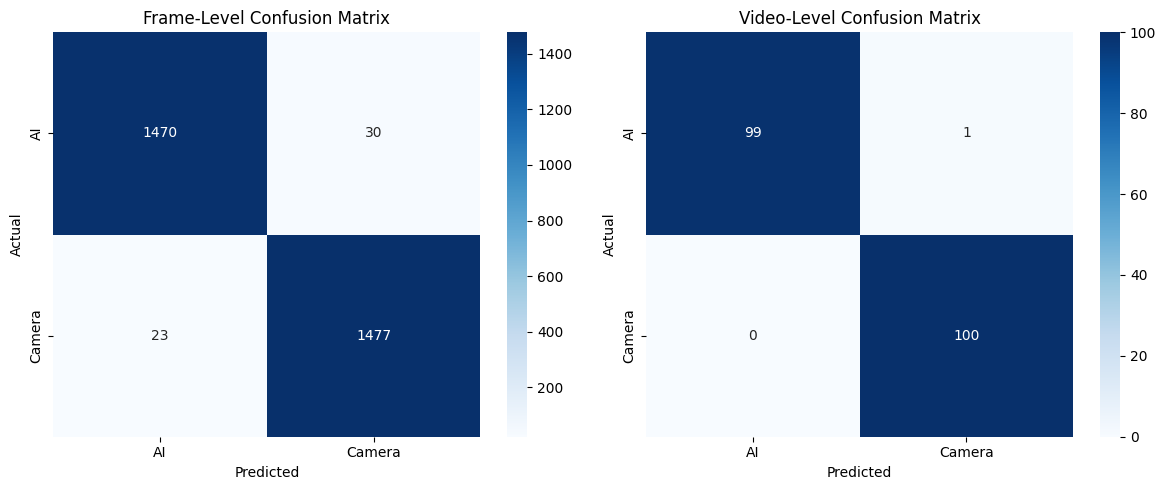

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Frame-level confusion matrix
sns.heatmap(
    confusion_matrix(y_true_frame, y_pred_frame),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['AI', 'Camera'],
    yticklabels=['AI', 'Camera'],
    ax=axes[0]
)
axes[0].set_title('Frame-Level Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Video-level confusion matrix
sns.heatmap(
    video_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['AI', 'Camera'],
    yticklabels=['AI', 'Camera'],
    ax=axes[1]
)
axes[1].set_title('Video-Level Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

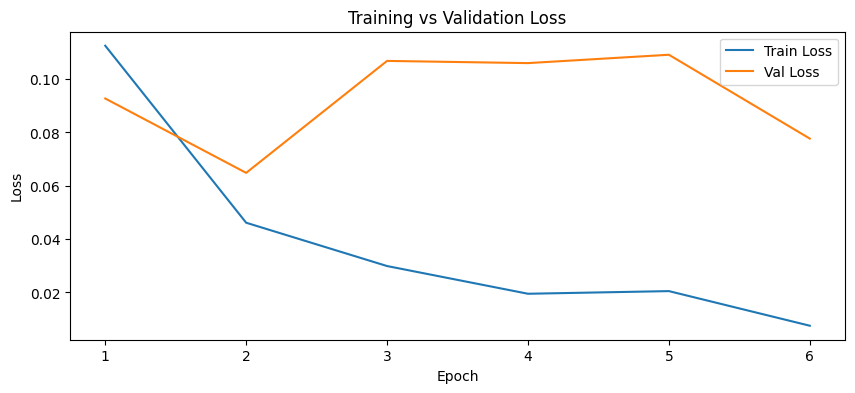

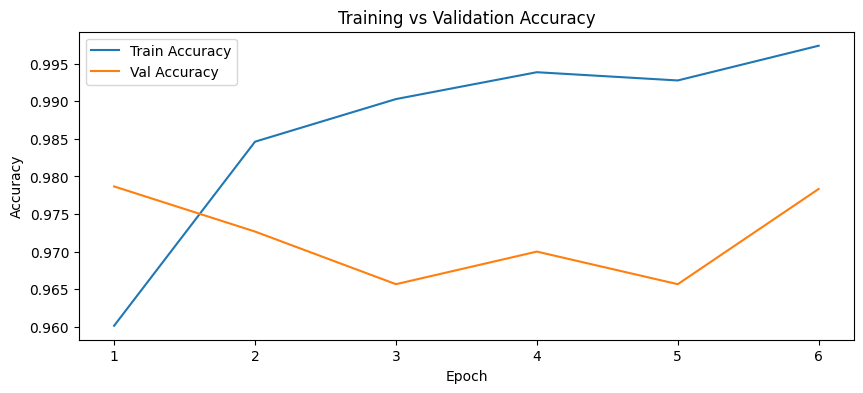

In [18]:
import matplotlib.pyplot as plt

epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)

plt.figure(figsize=(10, 4))
plt.plot(x, history["train_loss"], label="Train Loss")
plt.plot(x, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, history["train_acc"], label="Train Accuracy")
plt.plot(x, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()